# Coinbase Premium — the quant teardown 🪙

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Dead_since_the_ETFs%3F: Busted](https://img.shields.io/badge/Dead_since_the_ETFs%3F-Busted-8b949e?style=flat-square)

**Claim under test:** when US institutions buy, Coinbase BTC-USD trades rich to Binance BTCUSDT, and the premium **leads** BTC returns (the CryptoQuant "Coinbase Premium Gap" folklore of the 2020-21 bull).

**Tape:** Coinbase Exchange `/products/BTC-USD/candles` vs Binance `/api/v3/klines` BTCUSDT, UTC daily closes on the same 00:00 boundary, 2017-08-17 → 2026-06-30 (3,240 joint days, 8.9 yrs). As-of **2026-06-30**, fingerprint `73bf2b138404`. Cache-first; `data.fetch_daily(fetch=True)` touches the network exactly once.

**Named caveat:** the Binance leg is **USDT** — the series mixes the Coinbase USD bid with the Tether peg. We carry a 1%/99% winsorized robustness leg for exactly that. No survivorship (one asset, two venues, both alive throughout).

> 💡 **In plain words:** we price the same coin in two shops at the same instant, and ask whether the gap between the tickets tells you anything about tomorrow.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coinbase_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DF = data.load_real()                          # pinned as-of; cache-first
    PREM = st.premium_bps(DF)
    RET = st.log_returns(DF)
else:
    DF = PREM = RET = None
print("real cb/bn cache present:", HAVE_REAL,
      "| days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2017-08-17', 'end': '2026-06-30', 'asof': '2026-06-30', 'n_days': 3240, 'years': 8.9, 'fingerprint': '73bf2b138404', 'prem_mean': 1.54, 'prem_sd': 64.0, 'prem_min': -535.2, 'prem_max': 1335.3, 'ac1': 0.71, 'contemp_corr': 0.077, 'contemp_t': 1.91, 'yearly': [(2017, 107.37, 198.66, 76), (2018, -33.84, 110.9, 42), (2019, -4.45, 57.85, 54), (2020, 5.95, 14.16, 72), (2021, 5.94, 6.71, 88), (2022, -1.08, 7.04, 61), (2023, 3.19, 9.6, 75), (2024, -0.02, 6.82, 52), (2025, 0.43, 4.78, 60), (2026, -5.62, 6.28, 20)], 'neg2026': (145, 181), 'pred_raw': [(1, 12.47, 1.42), (2, 23.08, 1.76), (3, 37.97, 2.09), (5, 53.36, 1.48), (7, 61.37, 1.16)], 'pred_wins': [(1, 20.81, 2.3), (2, 32.98, 2.22), (3, 46.99, 2.1), (5, 68.38, 1.71), (7, 90.72, 1.63)], 'pred_chg': [(1, 2.39, 0.22), (2, -3.22, -0.26), (3, -2.04, -0.17), (5, 12.19, 1.12), (7, 6.5, 0.62)], 'winsor_lo': -215.8, 'winsor_hi': 178.7, 'split_rich': 17.77, 'split_cheap': 0.18, 'split_welch': 1.4, 'n_rich': 1533, 'n_cheap': 1676, 'overlay': [(5.0, 7.38, 1.67, 0.56, 30.9, 3.55, 1.13), (10.0, 6.34, 1.43, 0.48, 26.1, 2.52, 0.8), (25.0, 3.24, 0.73, 0.24, 12.6, -0.58, -0.18)], 'gross_bps': 8.41, 'exposure': 47.3, 'turnover': 76, 'bh_bps': 8.07, 'bh_sharpe': 0.43, 'bh_ann': 34.3, 'zrobust': [(20, 10.63, 2.52, 6.68, 2.15), (63, 6.34, 1.43, 2.52, 0.8), (126, 8.54, 1.96, 4.58, 1.48)], 'rand_mean': -1.46, 'rand_sd': 2.98, 'rand_t': -0.33, 'rand_seeds': 20, 'eras': [('2017-2019', 867, 0.85, 122.83, 19.89, 1.21, 6.02, 0.86), ('2020-2021', 731, 5.95, 11.08, 10.43, 0.56, -6.04, -0.79), ('2022', 365, -1.08, 7.04, 4.95, 0.29, 7.14, 0.69), ('2023+', 1277, 0.23, 7.68, 29.15, 2.87, 1.23, 0.34), ('2024+ (ETF era)', 912, -0.95, 6.4, 16.9, 1.8, 4.24, 0.97)], 'slope_pre': 0.175, 'slope_post': 3.793, 'slope_ratio': 22, 'slope_diff_t': 2.72, 'syn': [(0.0, 4.75, 0.75), (0.003, 34.05, 5.35)]}


real cb/bn cache present: True | days: 3240


## 1 · The premium series

Mean **+1.54 bps**, sd **64.00**, range **-535 → +1335 bps**, AC(1) **0.71** (persistent — hence HAC everywhere). Contemporaneously the premium co-moves with same-day returns: corr **+0.077** (HAC *t* +1.91) — a genuine *coincident* tell.

> 💡 **In plain words:** the gap is tiny on the average day (a hundredth of a percent) but sticky — a rich day is usually followed by another rich day.

In [2]:
# Recompute the series stats live from the cache (must match R / docs/results.md).
if HAVE_REAL:
    print('days %d  %s -> %s  fingerprint %s' % (len(DF), DF.index.min().date(),
          DF.index.max().date(), data.fingerprint(DF)))
    print('premium: mean %+.2f  sd %.2f  min %+.1f  max %+.1f  AC1 %.3f' % (
        PREM.mean(), PREM.std(ddof=1), PREM.min(), PREM.max(), PREM.autocorr(1)))
    yt = st.yearly_table(PREM)
    print(yt.round(2))
else:
    print('cache missing; frozen yearly table:', R['yearly'])


days 3240  2017-08-17 -> 2026-06-30  fingerprint 73bf2b138404
premium: mean +1.54  sd 64.00  min -535.2  max +1335.3  AC1 0.710
      mean_bps  sd_bps  pos_share    n
date                                  
2017    107.37  198.66       0.76  137
2018    -33.84  110.90       0.42  365
2019     -4.45   57.85       0.54  365
2020      5.95   14.16       0.72  366
2021      5.94    6.71       0.88  365
2022     -1.08    7.04       0.61  365
2023      3.19    9.60       0.75  365
2024     -0.02    6.82       0.52  366
2025      0.43    4.78       0.60  365
2026     -5.62    6.28       0.20  181


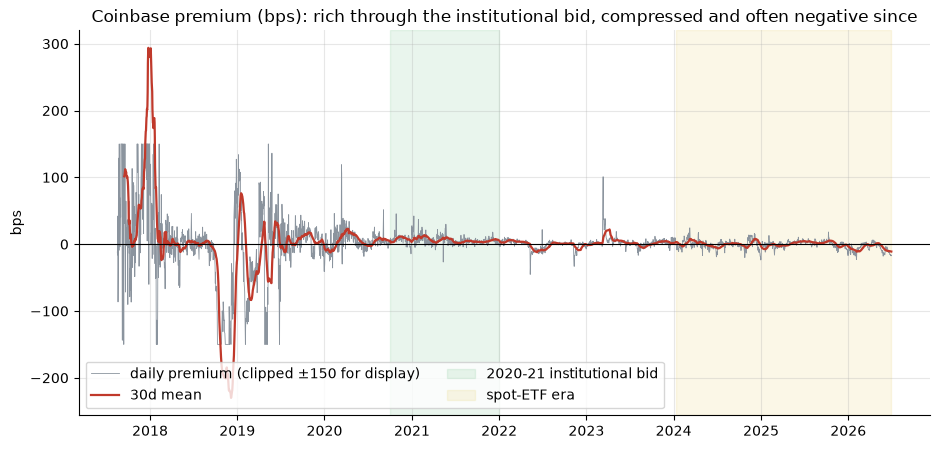

In [3]:
# The series + the two regimes that matter (institutional bid, ETF era).
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    clipped = PREM.clip(-150, 150)
    ax.plot(clipped.index, clipped.values, color=GREY, lw=0.6,
            label='daily premium (clipped \u00b1150 for display)')
    ax.plot(PREM.rolling(30).mean().index, PREM.rolling(30).mean().values,
            color=RED, lw=1.6, label='30d mean')
    ax.axhline(0, color='k', lw=0.8)
    ax.axvspan(pd.Timestamp('2020-10-01'), pd.Timestamp('2021-12-31'), color=GREEN,
               alpha=0.10, label='2020-21 institutional bid')
    ax.axvspan(pd.Timestamp('2024-01-11'), PREM.index.max(), color=AMBER,
               alpha=0.10, label='spot-ETF era')
    ax.set_ylabel('bps'); ax.legend(loc='lower left', ncols=2)
    ax.set_title('Coinbase premium (bps): rich through the institutional bid, compressed and often negative since')
    plt.tight_layout(); plt.show()


## 2 · Predictive regressions — the claim as stated

Forward *h*-day Coinbase log return on today's premium **level**; Newey-West *t* with lags = *h* + 2 (covers the forward-window overlap). Beta per +1 sd of the signal. The **raw level is the claim**; the winsorized leg (clip at the 1%/99% quantiles, -215.8/+178.7 bps) strips the USDT-depeg tails; the 1-day **change** tests the "premium *expansion* is the trigger" variant.

> 💡 **In plain words:** we let today's gap try to predict tomorrow (and up to a week out), scoring it with a statistic that can't be fooled by the gap's stickiness.

In [4]:
# Live recompute (must match the frozen R table).
if HAVE_REAL:
    for lab, kw in [('LEVEL raw', dict(signal='level')),
                    ('LEVEL winsorized 1%/99%', dict(signal='level', winsor=0.01)),
                    ('1-DAY CHANGE', dict(signal='change'))]:
        t = st.predictive_table(DF, **kw)
        print(lab); print(t.round(3).to_string()); print()


LEVEL raw
   beta_bps_per_sd  hac_t   corr     n
h                                     
1           12.473  1.420  0.035  3239
2           23.078  1.764  0.047  3238
3           37.966  2.094  0.063  3237
5           53.362  1.485  0.068  3235
7           61.369  1.157  0.065  3233

LEVEL winsorized 1%/99%
   beta_bps_per_sd  hac_t   corr     n
h                                     
1           20.809  2.302  0.058  3239
2           32.979  2.220  0.067  3238
3           46.990  2.097  0.078  3237
5           68.380  1.709  0.087  3235
7           90.721  1.634  0.096  3233

1-DAY CHANGE
   beta_bps_per_sd  hac_t   corr     n
h                                     
1            2.387  0.221  0.007  3238
2           -3.215 -0.256 -0.007  3237
3           -2.035 -0.165 -0.003  3236
5           12.189  1.119  0.015  3234
7            6.504  0.617  0.007  3232



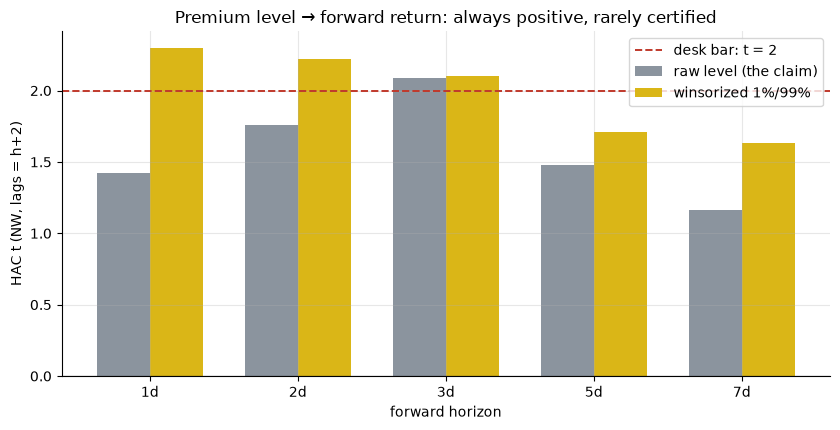

In [5]:
# t-stat profile across horizons, raw vs winsorized, with the desk bar at t = 2.
hs = [h for h, b, t in R['pred_raw']]
t_raw = [t for h, b, t in R['pred_raw']]
t_win = [t for h, b, t in R['pred_wins']]
x = np.arange(len(hs)); w = 0.36
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(x - w/2, t_raw, w, color=GREY, label='raw level (the claim)')
ax.bar(x + w/2, t_win, w, color=AMBER, label='winsorized 1%/99%')
ax.axhline(2.0, color=RED, lw=1.4, ls='--', label='desk bar: t = 2')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x, [f'{h}d' for h in hs]); ax.set_xlabel('forward horizon')
ax.set_ylabel('HAC t (NW, lags = h+2)')
ax.set_title('Premium level \u2192 forward return: always positive, rarely certified')
ax.legend(); plt.tight_layout(); plt.show()


Raw h = 1 sits at **+1.42** — the headline claim does not clear the bar on 8.9 years of tape. Winsorizing lifts h = 1-3 to **2.10-2.30** and raw h = 3 touches **2.09**: the whisper firms exactly when you clean the peg noise, but those legs inherit the cleaning choice. The 1-day change predicts nothing (max |*t*| = 1.12). Group split, same story: rich days (z63 > 0) → **+17.77 bps** next day vs cheap days **+0.18** — Welch *t* only **+1.40** against crypto's ±370 bps daily noise.

> 💡 **In plain words:** a 17-bps-a-day edge sounds enormous, but Bitcoin's daily swings are twenty times that. You need years more data — or a cleaner signal — to tell it from luck.

## 3 · Tradability — cost-charged overlay + the honest twins

Long BTC for day *t+1* iff trailing 63-day z(premium) > 0 at close *t*. **Exactly one execution lag**; 47.3% exposure; ~76 position changes/yr; one-way bps × traded NAV per change; long-only, no borrow; rf = 0 on both Sharpe legs (labeled). Timing alpha = net − exposure × B&H, the day-by-day surplus over a static position with the same market time.

In [6]:
# Live overlay recompute + the 20-seed exposure-matched random twin.
if HAVE_REAL:
    for cb in (5.0, 10.0, 25.0):
        ov = st.overlay(DF, cost_bps=cb)
        at = st.timing_alpha_t(DF, cost_bps=cb)
        print('cost %4.1f bps: net %+5.2f bps/d (HAC t %+5.2f, Sharpe %.2f) | '
              'alpha %+5.2f bps/d (t %+5.2f)' % (cb, ov['net_bps_d'], ov['net_t'],
              ov['net_sharpe'], ov['alpha_bps_d'], at))
    ov = st.overlay(DF, cost_bps=10.0)
    print('B&H %+5.2f bps/d (Sharpe %.2f)' % (ov['bh_bps_d'], ov['bh_sharpe']))
    rb = st.random_baseline(DF, exposure=ov['exposure'], cost_bps=10.0, n_seeds=20)
    print('random twin (%d seeds): %+0.2f +/- %.2f bps/d, mean HAC t %+0.2f' % (
          rb['n_seeds'], rb['mean_bps_d'], rb['sd_bps_d'], rb['mean_hac_t']))
    for w_ in (20, 63, 126):
        o2 = st.overlay(DF, z_window=w_, cost_bps=10.0)
        print('z%3d: alpha %+5.2f bps/d (t %+5.2f)' % (w_, o2['alpha_bps_d'],
              st.timing_alpha_t(DF, z_window=w_, cost_bps=10.0)))


cost  5.0 bps: net +7.38 bps/d (HAC t +1.67, Sharpe 0.56) | alpha +3.55 bps/d (t +1.13)
cost 10.0 bps: net +6.34 bps/d (HAC t +1.43, Sharpe 0.48) | alpha +2.52 bps/d (t +0.80)
cost 25.0 bps: net +3.24 bps/d (HAC t +0.73, Sharpe 0.24) | alpha -0.58 bps/d (t -0.18)
B&H +8.07 bps/d (Sharpe 0.43)


random twin (20 seeds): -1.46 +/- 2.98 bps/d, mean HAC t -0.33
z 20: alpha +6.68 bps/d (t +2.15)
z 63: alpha +2.52 bps/d (t +0.80)
z126: alpha +4.58 bps/d (t +1.48)


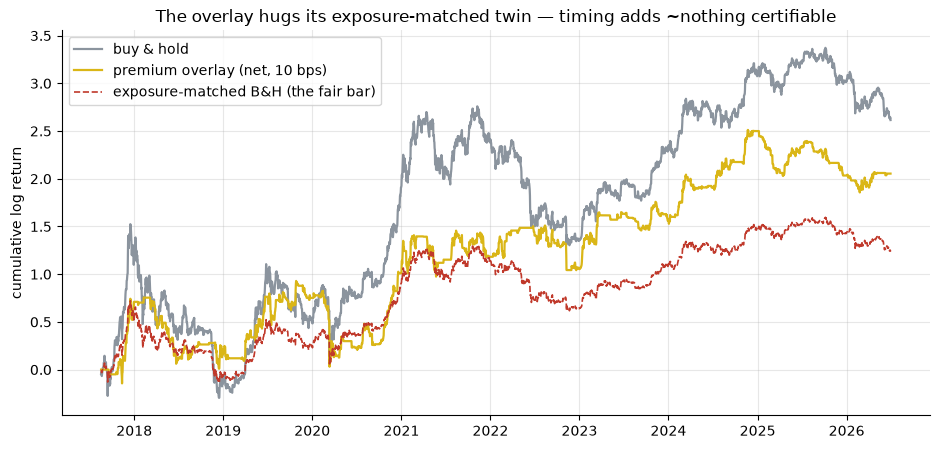

In [7]:
# Cumulative log-equity: overlay (net, 10 bps) vs buy & hold vs exposure-matched B&H.
if HAVE_REAL:
    ov = st.overlay(DF, cost_bps=10.0)
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.plot(ov['bh'].cumsum().index, ov['bh'].cumsum().values, color=GREY, lw=1.6,
            label='buy & hold')
    ax.plot(ov['net'].cumsum().index, ov['net'].cumsum().values, color=AMBER, lw=1.6,
            label='premium overlay (net, 10 bps)')
    matched = (ov['exposure'] * ov['bh']).cumsum()
    ax.plot(matched.index, matched.values, color=RED, lw=1.2, ls='--',
            label='exposure-matched B&H (the fair bar)')
    ax.set_ylabel('cumulative log return')
    ax.set_title('The overlay hugs its exposure-matched twin — timing adds ~nothing certifiable')
    ax.legend(); plt.tight_layout(); plt.show()


Net of 10 bps the overlay earns **+6.34 bps/d** (Sharpe 0.48) vs B&H **+8.07** (Sharpe 0.43) — it *underperforms* holding. Timing alpha: **+0.80σ** at 10 bps, **-0.18σ** at 25 bps. Window robustness: z20/z63/z126 alpha *t* = **+2.15 / +0.80 / +1.48** — one knob setting clears, its neighbours don't: spec search, not edge. The 20-seed random twin: -1.46 ± 2.98 bps/d (mean HAC *t* -0.33) — the machinery pays nothing for luck.

> 💡 **In plain words:** after fees, the "institutional radar" strategy makes *less* than doing nothing, and its skill is statistically a coin flip.

## 4 · Eras + the third axis — did the ETFs kill it?

Pre-registered myth-check: since 2024 the US institutional bid clears through **spot ETFs**, not Coinbase — so the premium signal should be **dead** post-2022. Era cards, then an HAC-SE test of the pre-2023 vs 2023+ slope *difference* (the split is the pre-registered one, not snooped).

In [8]:
# Live era recompute + slope-difference test.
if HAVE_REAL:
    eras = [('2017-2019', None, '2019-12-31'), ('2020-2021', '2020-01-01', '2021-12-31'),
            ('2022', '2022-01-01', '2022-12-31'), ('2023+', '2023-01-01', None),
            ('2024+ (ETF era)', '2024-01-01', None)]
    for name, s, e in eras:
        es = st.era_summary(st.slice_df(DF, s, e))
        print('%-16s n=%4d prem %+7.2f (sd %6.2f)  beta %+7.2f bps/sd  t %+5.2f  '
              'alpha %+6.2f (t %+5.2f)' % (name, es['n'], es['prem_mean_bps'],
              es['prem_sd_bps'], es['beta_bps_per_sd'], es['pred_t'],
              es['alpha_bps_d'], es['alpha_t']))
    pre = st.slice_df(DF, None, '2022-12-31'); post = st.slice_df(DF, '2023-01-01', None)
    def _slope(d):
        p = st.premium_bps(d); y = st.forward_return(st.log_returns(d), 1)
        r = st.hac_slope(p.to_numpy(), y.to_numpy(), lags=3)
        return r['beta'], r['beta'] / r['t']
    b1, se1 = _slope(pre); b2, se2 = _slope(post)
    print('slope pre %+0.3f bps/bp vs post %+0.3f bps/bp (%0.0fx)  diff t = %+0.2f' % (
          b1*1e4, b2*1e4, b2/b1, (b2-b1)/np.hypot(se1, se2)))


2017-2019        n= 867 prem   +0.85 (sd 122.83)  beta  +19.89 bps/sd  t +1.21  alpha  +6.02 (t +0.86)
2020-2021        n= 731 prem   +5.95 (sd  11.08)  beta  +10.43 bps/sd  t +0.56  alpha  -6.04 (t -0.79)
2022             n= 365 prem   -1.08 (sd   7.04)  beta   +4.95 bps/sd  t +0.29  alpha  +7.14 (t +0.69)
2023+            n=1277 prem   +0.23 (sd   7.68)  beta  +29.15 bps/sd  t +2.87  alpha  +1.23 (t +0.34)
2024+ (ETF era)  n= 912 prem   -0.95 (sd   6.40)  beta  +16.90 bps/sd  t +1.80  alpha  +4.24 (t +0.97)
slope pre +0.175 bps/bp vs post +3.793 bps/bp (22x)  diff t = +2.72


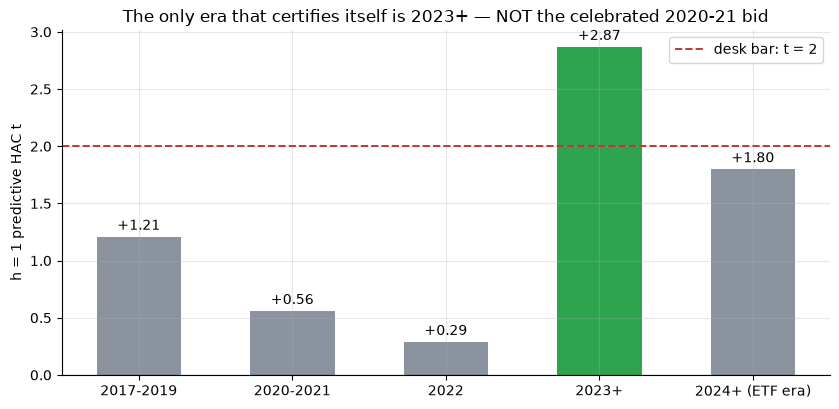

In [9]:
# Era profile: predictive t (bars, desk bar at 2) -- the 2023+ surprise.
labs = [e[0] for e in R['eras']]
ts = [e[5] for e in R['eras']]
colors = [GREEN if t >= 2 else GREY for t in ts]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(labs, ts, color=colors, width=0.55)
ax.axhline(2.0, color=RED, lw=1.4, ls='--', label='desk bar: t = 2')
ax.axhline(0, color='k', lw=0.8)
for i, t in enumerate(ts):
    ax.annotate(f'{t:+.2f}', (i, t + 0.06), ha='center', fontsize=10)
ax.set_ylabel('h = 1 predictive HAC t')
ax.set_title('The only era that certifies itself is 2023+ — NOT the celebrated 2020-21 bid')
ax.legend(); plt.tight_layout(); plt.show()


**Busted.** The premium compressed ~10-20× (sd 123 → 6.4 bps) and 2026 H1 is negative on 145/181 days — but per bp the slope is **22× larger** in 2023+ (+3.793 vs +0.175 bps/bp, difference *t* = **+2.72**), and 2023+ is the only slice clearing the bar alone (*t* = +2.87). The 2024+ ETF-era sub-sample reads +1.80 — sharper but too thin to re-certify on its own. And the era the folklore celebrates, 2020-21, predicts *nothing* (*t* = +0.56): the premium was rich, but knowing so earned you nothing extra.

> 💡 **In plain words:** the ETFs shrank the footprint but made each remaining basis point more meaningful — the exact opposite of "dead". Still too faint to trade.

## 5 · Synthetic control — machinery proof *(never market evidence)*

A deterministic two-venue world: shared random-walk BTC, AR(1) premium (φ = 0.9, sd 25 bps), and a plantable **lead knob** adding `lead × z(premium)` to the *next* day's return. Null (lead = 0) must stay quiet; a planted lead must light up.

In [10]:
# No network; seeds fixed.
for lead in (0.0, 0.003):
    syn = data.synthetic_world(lead=lead)
    pt = st.predictive_table(syn, horizons=(1,), signal='level')
    print('planted lead=%.3f: h=1 beta %+7.2f bps/sd  HAC t %+6.2f' % (
          lead, pt['beta_bps_per_sd'].iloc[0], pt['hac_t'].iloc[0]))


planted lead=0.000: h=1 beta   +4.75 bps/sd  HAC t  +0.75
planted lead=0.003: h=1 beta  +34.05 bps/sd  HAC t  +5.35


Null: *t* = **+0.75** (quiet). Planted lead: *t* = **+5.35** (lights up). The real-tape *t*'s are read off an honest instrument — which makes the +1.42 all the more damning.

## 6 · Verdict

- **Signal — WEAK.** Direction positive at every horizon and era; raw headline HAC *t* = **+1.42**; only spec-assisted legs (winsorized 2.10-2.30, h = 3 at 2.09, 2023+ at 2.87) clear the bar; the celebrated 2020-21 era predicts nothing (+0.56).
- **Tradability — MIRAGE.** Timing alpha +0.80σ at 10 bps, negative at 25 bps, window-fragile (2.15/0.80/1.48 across z20/z63/z126); underperforms buy & hold at every cost; 20-seed random twin ≈ 0.
- **"Dead since the ETFs?" — BUSTED.** Compressed 10-20×, yet 22× sharper per bp (difference *t* = +2.72); 2023+ is the only self-certifying slice. Shrunk and sharpened — not dead, and still not tradable.

*Every number: `python examples/verify.py` · frozen in `docs/results.md` (as-of 2026-06-30, fingerprint `73bf2b138404`). Not investment advice.*